In [1]:
from regions import ROSS_BOUNDS

# use dfngp_env
import numpy as np
import pandas as pd
import torch
from pyproj import CRS, Transformer
import xarray as xr
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import os

In [2]:
from regions import ROSS_BOUNDS

x_min = ROSS_BOUNDS["x_min"]
x_max = ROSS_BOUNDS["x_max"]
y_min = ROSS_BOUNDS["y_min"]
y_max = ROSS_BOUNDS["y_max"]

# Load data

- **smb_rec.1979-2021.BN_RACMO2.3p2_ANT27_ERA5-3h.AIS.2km.YY.nc**: map of annual SMB (kg per m² or mm w.e. per year) from ERA5-forced RACMO2.3p2 at 27 km, statistically downscaled to 2 km resolution, covering the whole of Antarctica (1979-2021).

In [3]:
# define path to folder
path_to_folder = "/home/kim/data/smb_2km/smb_rec.1979-2021.RACMO2.3p2_ANT27_ERA5-3h.AIS.2km.YY.nc"
# load dataset
smb = xr.load_dataset(path_to_folder)
# insepct
print(smb.smb_rec.values.shape)

(43, 2303, 2778)


## Units

| Field    | Description                                                                           |
| -------- | ------------------------------------------------------------------------------------- |
| `time`   | 1979–2021 (yearly data)                                                               |
| `x`, `y` | Already in Antarctic Polar Stereographic Projection [EPSG:3031](https://epsg.io/3031) |
| `smb`    | **mm w.e. per year**                                                                  |


# Subset area

In [4]:
# Using Ross bounds
smb_ross = smb.sel(
    x = slice(x_min, x_max),
    y = slice(y_min, y_max),
)

smb_ross

<xarray.Dataset> Size: 43MB
Dimensions:  (time: 43, x: 500, y: 501)
Coordinates:
  * time     (time) datetime64[ns] 344B 1979-06-30T18:00:00.662224896 ... 202...
  * x        (x) float32 2kB -5.99e+05 -5.97e+05 -5.95e+05 ... 3.97e+05 3.99e+05
  * y        (y) float32 2kB -1.4e+06 -1.398e+06 -1.396e+06 ... -4.02e+05 -4e+05
Data variables:
    smb_rec  (time, y, x) float32 43MB 0.0 0.0 0.0 0.0 ... 10.81 10.9 11.39
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    grid:         Map Projection: Antarctic Polar Stereographic EPSG3031 - Ma...
    netcdf:       4.7.4 of Apr 18 2020 10:56:44 $
    frequency:    mon
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...
    institution:  IMAU/ULiège (Brice Noël)
    NCO:          netCDF Operators version 5.1.7 (Homepage = http://nco.sf.ne...
    title:        Annual SMB field at 2km (RACMO2.3p2) ERA

# Average over years

In [5]:
min_year = 1980
max_year = 2010

# select years
smb_ross_span = smb_ross.sel(time = slice(f"{min_year}-01-01", f"{max_year}-12-31"))
# compute longterm mean
smb_ross_longterm_mean = smb_ross_span.mean(dim = ("time"))

# Plot

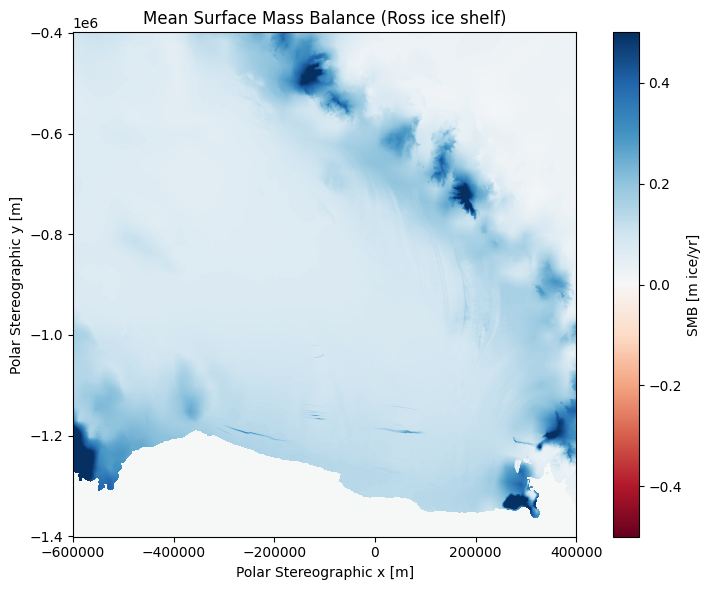

In [6]:
# Determine symmetric color limits around zero
vmax = 0.5
vmin = - 0.5

# Plot
plt.figure(figsize = (8, 6))
pcm = plt.pcolormesh(
    smb_ross_longterm_mean.x,
    smb_ross_longterm_mean.y,
    smb_ross_longterm_mean.smb_rec / 1000,  # convert from mm to m
    cmap = "RdBu",
    vmin = vmin,
    vmax = vmax,
    shading = "auto"    
)
plt.colorbar(pcm, label = "SMB [m ice/yr]")
plt.title("Mean Surface Mass Balance (Ross ice shelf)")
plt.xlabel("Polar Stereographic x [m]")
plt.ylabel("Polar Stereographic y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

# Interpolate at target grid

In [7]:
# Load target grid
target_grid_mask = xr.load_dataset("data/target_grid_mask.nc")

# Interpolate smb onto the target grid's x/y
smb_on_target = smb_ross_longterm_mean.interp(
    x = target_grid_mask["x"],
    y = target_grid_mask["y"],
    # Note: cubic had issues
    method = "linear",
)

# Add mask from target grid as second variable
smb_on_target["mask"] = target_grid_mask.mask

In [8]:
smb_masked = smb_on_target.smb_rec.where(smb_on_target["mask"] > 0)

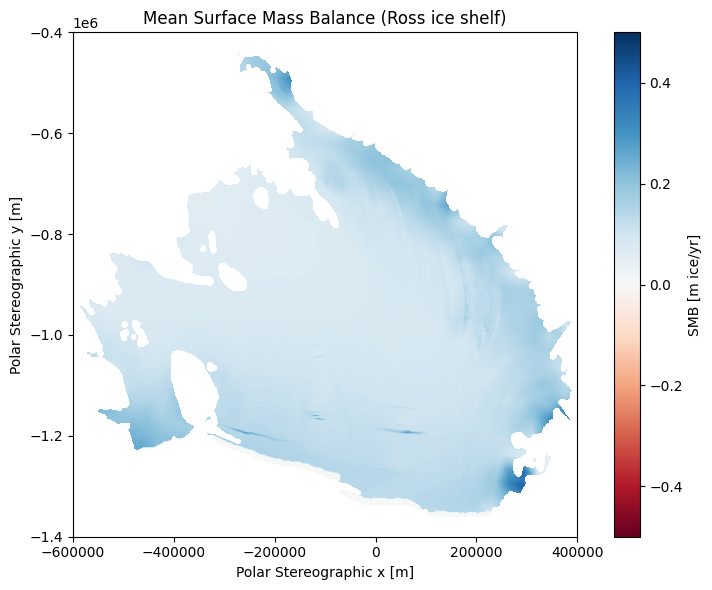

In [9]:
# Plot
plt.figure(figsize = (8, 6))
pcm = plt.pcolormesh(
    smb_masked.x,
    smb_masked.y,
    smb_masked / 1000,  # convert from mm to m
    cmap = "RdBu",
    vmin = vmin,
    vmax = vmax,
    shading = "auto"    
)
plt.colorbar(pcm, label = "SMB [m ice/yr]")
plt.title("Mean Surface Mass Balance (Ross ice shelf)")
plt.xlabel("Polar Stereographic x [m]")
plt.ylabel("Polar Stereographic y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

# Load MODIS background

In [10]:
modis_ross = torch.load("data/modis/moa125_2014_hp1_v01_ross_with_grid_no_ocean.pt", weights_only = False)
modis_ross.shape

(3, 7999, 8000)

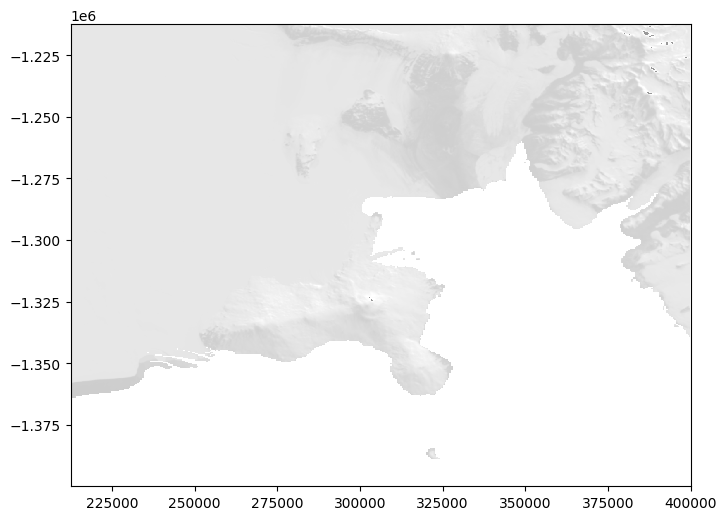

In [11]:
fig, ax = plt.subplots(figsize = (8, 6))

# 1) MODIS as background (draw first)
ax.pcolormesh(
    modis_ross[0, -1500:, -1500:],
    modis_ross[1, -1500:, -1500:], 
    modis_ross[2, -1500:, -1500:],
    cmap = "gray",
    # 2 - 98 pertentile is 7_000 to 17_000
    vmin = -30_000, vmax = 30_000,
    alpha = 0.4,
    zorder = 0,
)

plt.show()

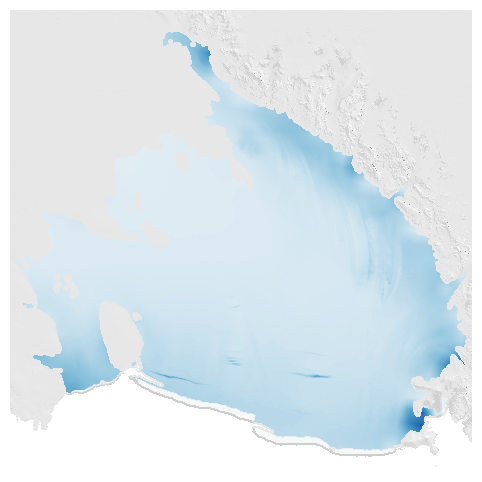

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (8, 6))

# 1) MODIS as background (draw first)
ax.pcolormesh(
    modis_ross[0],
    modis_ross[1], 
    modis_ross[2],
    cmap = "gray",
    # softer greys
    vmin = -30_000, 
    vmax = 30_000,
    # as less saturated background
    alpha = 0.4,
    zorder = 0,
)

# 2) SMB on top (draw second)
pcm = ax.pcolormesh(
    smb_masked.x,
    smb_masked.y,
    # mm -> m
    smb_masked / 1000,
    cmap = "RdBu",
    vmin = vmin,
    vmax = vmax,
    shading = "auto",
    # 1.0 for full opacity & consistency
    alpha = 1.0,
    zorder = 1,
)

ax.set_aspect("equal")
ax.set_axis_off()

fig.savefig("figures/smb_ross.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()

# Add to file

In [13]:
path = "data/fluxnet_div_ross.nc"

# 1) Open -> load into memory -> close file handle
with xr.open_dataset(path) as _ds:
    ds = _ds.load()

# 2) Add Noël SMB (convert mm -> m)
ds["noel_smb"] = (("y", "x"), (smb_masked / 1000.0).values)
ds["noel_smb"].attrs.update({
    "long_name": "Noël surface mass balance (SMB) on target grid",
    "units": "m yr-1",
    "note": "Converted from mm yr-1 to m yr-1 by dividing by 1000",
})

# 3) Safe overwrite to SAME pathname (write temp, then atomic replace)
tmp_path = path + ".tmp"
ds.to_netcdf(tmp_path, mode = "w")
os.replace(tmp_path, path)